# 1. LIBRARIES

In [1]:
import os
import sys
from pathlib import Path

# Add project root to sys.path to allow imports from functions_final.py
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl
import seaborn as sns
import joblib

# Import functions from functions_final.py
from functions_final import *
from UQpy.distributions import Uniform, JointIndependent

# Set matplotlib parameters for better aesthetics
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False,
                        'figure.dpi': 100
                    })

/home/wmpjrufg/Documents/2024-1_victor_hugo_renata_maria/myenv/lib/python3.12/site-packages/UQpy/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# 2. LOADING THE CARBONATION MODEL

In [2]:
# Path to the trained model
# name_best_model = r'D:\Documentos\ic_victor\beam_problem_1\model_NeuralNetwork_MLP_fold_4.pkl'
name_best_model = r'/home/wmpjrufg/Documents/2024-1_victor_hugo_renata_maria/beam_problem_1/model_NeuralNetwork_MLP_fold_4.pkl'

# Load the model
model = joblib.load(name_best_model)

print("Carbonation model loaded successfully!")
print(f"   Expected features: {model.feature_names_in_}")

Carbonation model loaded successfully!
   Expected features: ['CO2 (%)' 'fc (MPa)' 'RH (%)' 'Type of cement' 'Exposure conditions'
 't (years)']


In [3]:
# Defines the geometric properties, material properties, loads, and exposure conditions of the beam.
# The values here are deterministic and will be overwritten by random samples.

# Geometric properties
geo = {
    'b_w [m]': 0.20,           # Beam width [m]
    'h [m]': 0.25,             # Beam height [m]
    'l [m]': 6.00,             # Beam span [m]
    'n bars': 4,               # Number of steel bars
    'phi [m]': 0.0125,         # Bar diameter [m] (12.5 mm)
    'ratio d/h': 0.84,         # Ratio of effective depth to total height
    'cover [m]': 0.015         # Nominal cover [m] (will be overwritten)
}

# Material properties
mat = {
    'f_yk [kPa]': 500E3,       # Characteristic steel strength [kPa]
    'f_ck [kPa]': 25E3,        # Characteristic concrete strength [kPa] (will be overwritten)
    'e_s [kPa]': 200E6,        # Steel elastic modulus [kPa]
    'gamma_c': 1.0,            # Concrete safety factor
    'gamma_s': 1.0,            # Steel safety factor
    'Type of cement': 2        # Cement type (2 = CPIV)
}

# Loads
load = {
    'g_k [kN/m]': 5.0,         # Permanent load [kN/m]
    'q_k [kN/m]': 2.0,         # Variable load [kN/m]
    'gamma_g': 1.0,            # Safety factor for permanent load
    'gamma_q': 1.0             # Safety factor for variable load
}

# Exposure conditions
expo = {
    'temp [°C]': 25.0,                 # Ambient temperature [°C]
    'Relative humidity [%]': 65.0,     # Relative humidity [%] (will be overwritten)
    'Installation year': 2000,         # Year of structure installation
    'Exposure conditions': 3,          # Exposure condition (2 = PEA - External Protected)
    'i_corr_20': 2.3                   # Corrosion index at 20°C [μA/cm²]
}

# Create the reference beam
beam_ref = Beam(geo, mat, load, expo)

# 4. DEFINITION OF RANDOM VARIABLES

Defines the probability distributions for the input variables:
- Concrete compressive strength (fck);
- Relative humidity (RH).

In [7]:
# Number of samples
n_samples        = 1000              # Number of design samples
n_latent_samples = 1000           # Number of latent samples per design sample

# Distributions of random variables
fck_dist   = Uniform(loc=25E3, scale=50E3 - 25E3)  # Strength: 25-50 MPa
rh_dist    = Uniform(loc=20, scale=80 - 20)        # Humidity: 20-80%

# Joint distribution
joint = JointIndependent(marginals=[fck_dist, rh_dist])

# Generate samples
x = joint.rvs(n_samples)

print("Samples generated successfully!")
print(f"   Number of design samples: {n_samples}")
print(f"   Number of latent samples per design sample: {n_latent_samples}")
print(f"   Total simulations: {n_samples * n_latent_samples}")
print("\nSample statistics:")
print(f"   fck:   {x[:, 0].min()/1000:.1f} - {x[:, 0].max()/1000:.1f} MPa (mean: {x[:, 0].mean()/1000:.1f} MPa)")
print(f"   RH:    {x[:, 1].min():.1f} - {x[:, 1].max():.1f}% (mean: {x[:, 1].mean():.1f}%)")

Samples generated successfully!
   Number of design samples: 1000
   Number of latent samples per design sample: 1000
   Total simulations: 1000000

Sample statistics:
   fck:   25.0 - 50.0 MPa (mean: 37.4 MPa)
   RH:    20.0 - 80.0% (mean: 50.5%)


# 6. EVALUATION OF CARBONATION PROGRESS USING GENERALIZED LAMBDA DISTRIBUTION

In [ ]:
# Executes the analysis for different service life times (0 to 100 years, step of 10 years).

# Times to be analyzed
times = np.arange(0, 101, 10)
results_list = []

print("="*60)
print("STARTING DURABILITY ANALYSIS")
print("="*60)

for t in times:
    print(f'\n{"-"*40}')
    print(f'PROCESSING TIME: {t} years')
    print(f'{"-"*40}')
    
    df = state_limit_function_time_durability(
                                                x=x,
                                                names_x_variables=["cover", "fck", "rh"],
                                                carb_model=model,
                                                cement_type=2,
                                                installation_year=2000,
                                                exposure_conditions=2,
                                                time_step=t,
                                                n_latent_samples=n_latent_samples,
                                                verbose=True
                                            )
    
    # ============================================================
    # DEMONSTRAÇÃO DOS VALORES POR SAMPLE
    # ============================================================
    
    print(f"\n   📊 DEMONSTRAÇÃO DOS DADOS PARA t = {t} anos:")
    print(f"   {'='*50}")
    
    # IMPORTANTE: NÃO REORDENAR! Manter a ordem original do DataFrame
    # Extrair um resumo por sample preservando a ordem de aparecimento
    samples_summary = df.groupby(['cover', 'fck', 'rh'], sort=False).agg({
        'Carbonation_depth_mm': ['mean', 'std'],
        'lambda 1': 'mean',
        'lambda 2': 'mean', 
        'lambda 3': 'mean',
        'lambda 4': 'mean'
    }).round(4)
    
    samples_summary.columns = ['Carbonation_mean_mm', 'Carbonation_std_mm', 
                                'λ1_mean', 'λ2_mean', 'λ3_mean', 'λ4_mean']
    samples_summary = samples_summary.reset_index()
    
    # Mostrar cada sample na ordem original
    for idx, row in samples_summary.iterrows():
        print(f"\n   📌 SAMPLE {idx+1} (ordem original da função):")
        print(f"      Entradas (X):")
        print(f"        - Cover: {row['cover']:.4f} m")
        print(f"        - fck:   {row['fck']:.2f} Pa")
        print(f"        - RH:    {row['rh']:.2f} %")
        print(f"      Carbonatação:")
        print(f"        - Média: {row['Carbonation_mean_mm']:.4f} mm")
        print(f"        - Desvio: {row['Carbonation_std_mm']:.4f} mm")
        print(f"      Saídas (Y) - Lambdas:")
        print(f"        - λ1: {row['λ1_mean']:.6f}")
        print(f"        - λ2: {row['λ2_mean']:.6f}")
        print(f"        - λ3: {row['λ3_mean']:.6f}")
        print(f"        - λ4: {row['λ4_mean']:.6f}")
    
    # ============================================================
    # PREPARAÇÃO DOS DADOS PARA PCE - MANTER ORDEM ORIGINAL
    # ============================================================
    
    # 1. Extrair os valores únicos de X (um por sample) - SEM REORDENAR
    X_pce = df[['cover', 'fck', 'rh']].drop_duplicates(keep='first').values
    
    # 2. Extrair os valores de Y (lambdas) - SEM REORDENAR, manter ordem do groupby
    y_pce = df.groupby(['cover', 'fck', 'rh'], sort=False)[['lambda 1', 'lambda 2', 'lambda 3', 'lambda 4']].mean().values
    
    print(f"\n   ✅ Dados preparados para PCE (mantendo ordem original):")
    print(f"      X_pce shape: {X_pce.shape}")
    print(f"      y_pce shape: {y_pce.shape}")
    
    # Verificação da ordem
    print(f"\n   🔍 VERIFICAÇÃO DA ORDEM (mesma da função):")
    for i in range(len(X_pce)):
        print(f"      Sample {i+1}: Cover={X_pce[i][0]:.4f}m → λ1={y_pce[i][0]:.4f}")
    
    # ============================================================
    # TREINAMENTO E SALVAMENTO DO PCE METAMODEL
    # ============================================================
    
    # Definir distribuições das variáveis de entrada
    cover_dist = Uniform(loc=0.015, scale=0.005)
    fck_dist = Uniform(loc=25E3, scale=50E3 - 25E3)
    rh_dist = Uniform(loc=20, scale=60)
    joint = JointIndependent(marginals=[cover_dist, fck_dist, rh_dist])
    
    # Configurar PCE
    max_degree = 3
    polynomial_basis = TotalDegreeBasis(joint, max_degree)
    least_squares = LeastSquareRegression()
    pce_metamodel = PolynomialChaosExpansion(polynomial_basis=polynomial_basis, 
                                              regression_method=least_squares)
    
    # Treinar o PCE
    pce_metamodel.fit(X_pce, y_pce)
    
    # Salvar o metamodelo
    filename = f'pce_metamodel_{t}.pkl'
    with open(filename, 'wb') as f:
        dill.dump(pce_metamodel, f)
    print(f"   💾 PCE metamodel saved as '{filename}'")
    
    # Validação rápida
    y_pred = pce_metamodel.predict(X_pce)
    max_error = np.max(np.abs(y_pred - y_pce))
    print(f"   ✓ PCE validation: Max prediction error = {max_error:.2e}")
    
    results_list.append(df)
    print(f'\n✅ Time {t} years completed!')

print("\n" + "="*60)
print("ANALYSIS COMPLETED FOR ALL TIMES!")
print("="*60)

# Save concatenated DataFrame
results_df = pd.concat(results_list, ignore_index=True)
results_df.to_excel('durability_analysis_results.xlsx', index=False)
results_df.to_pickle('durability_analysis_results.pkl')

print("\n📁 Results saved to:")
print("   - durability_analysis_results.xlsx")
print("   - durability_analysis_results.pkl")

STARTING DURABILITY ANALYSIS

----------------------------------------
PROCESSING TIME: 0 years
----------------------------------------
  Sample 1:
    P(g < 0) = 0.0000
    Mean carbonation depth = 1.28 mm
  Sample 2:
    P(g < 0) = 0.0000
    Mean carbonation depth = 0.54 mm

   📊 DEMONSTRAÇÃO DOS DADOS PARA t = 0 anos:

   📌 SAMPLE 1 (ordem original da função):
      Entradas (X):
        - Cover: 0.0298 m
        - fck:   49668.96 Pa
        - RH:    71.47 %
      Carbonatação:
        - Média: 1.2790 mm
        - Desvio: 0.0863 mm
      Saídas (Y) - Lambdas:
        - λ1: 28.437500
        - λ2: 11.152600
        - λ3: 4.288200
        - λ4: 0.111700

   📌 SAMPLE 2 (ordem original da função):
      Entradas (X):
        - Cover: 0.0229 m
        - fck:   48502.44 Pa
        - RH:    29.02 %
      Carbonatação:
        - Média: 0.5375 mm
        - Desvio: 0.0456 mm
      Saídas (Y) - Lambdas:
        - λ1: 22.402600
        - λ2: 33.430000
        - λ3: 0.095000
        - λ4: 0.12

# 6.1 TESTES DO PCE

In [20]:
import numpy as np
import pandas as pd
import dill
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ============================================================================
# VALIDAÇÃO DOS MODELOS PCE TREINADOS
# ============================================================================

# Tempos analisados
times = np.arange(0, 101, 10)

# Carregar os dados originais do Excel
df_original = pd.read_excel('durability_analysis_results.xlsx')

print("="*80)
print("VALIDAÇÃO DOS MODELOS PCE - PREVISÃO VS REAL")
print("="*80)

# Armazenar resultados
results = []

for t in times:
    print(f"\n{'='*60}")
    print(f"TEMPO: {t} anos")
    print(f"{'='*60}")
    
    # 1. Carregar o modelo PCE treinado
    filename = f'pce_metamodel_{t}.pkl'
    try:
        with open(filename, 'rb') as f:
            pce_model = dill.load(f)
        print(f"✓ Modelo carregado: {filename}")
    except FileNotFoundError:
        print(f"✗ Arquivo não encontrado: {filename}")
        continue
    
    # 2. Filtrar dados para este tempo
    df_t = df_original[df_original['Time (years)'] == t]
    
    # 3. Extrair X reais - USAR A MESMA ORDEM DO TREINAMENTO (ordenar por cover)
    #    O PCE foi treinado com X_pce ordenado por cover
    X_real = df_t[['cover', 'fck', 'rh']].drop_duplicates().sort_values('cover').values
    
    # 4. Extrair Y reais - USAR A MESMA ORDEM (ordenar por cover)
    y_real_df = df_t.groupby(['cover', 'fck', 'rh'])[['lambda 1', 'lambda 2', 'lambda 3', 'lambda 4']].mean().reset_index()
    y_real_df = y_real_df.sort_values('cover')
    y_real = y_real_df[['lambda 1', 'lambda 2', 'lambda 3', 'lambda 4']].values
    
    # 5. Fazer predições com o PCE
    y_pred = pce_model.predict(X_real)
    
    # 6. Calcular métricas de erro
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real.flatten(), y_pred.flatten())
    
    # 7. Mostrar resultados detalhados
    print(f"\n📊 RESULTADOS DA VALIDAÇÃO:")
    print(f"   Número de amostras: {len(X_real)}")
    print(f"   MSE:  {mse:.2e}")
    print(f"   RMSE: {rmse:.2e}")
    print(f"   MAE:  {mae:.2e}")
    print(f"   R²:   {r2:.10f}")
    
    print(f"\n📌 COMPARAÇÃO SAMPLE A SAMPLE (ordenado por cover):")
    print(f"   ┌─────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┐")
    print(f"   │ Smpl│     Cover    │    λ1 Real   │    λ1 Pred   │    λ2 Real   │    λ2 Pred   │")
    print(f"   ├─────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤")
    
    for i in range(len(X_real)):
        print(f"   │  {i+1}  │  {X_real[i][0]:.4f}  │  {y_real[i][0]:10.6f}  │  {y_pred[i][0]:10.6f}  │  {y_real[i][1]:10.6f}  │  {y_pred[i][1]:10.6f}  │")
    
    print(f"   └─────┴──────────────┴──────────────┴──────────────┴──────────────┴──────────────┘")
    
    print(f"\n   ┌─────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┐")
    print(f"   │ Smpl│     Cover    │    λ3 Real   │    λ3 Pred   │    λ4 Real   │    λ4 Pred   │")
    print(f"   ├─────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤")
    
    for i in range(len(X_real)):
        print(f"   │  {i+1}  │  {X_real[i][0]:.4f}  │  {y_real[i][2]:10.6f}  │  {y_pred[i][2]:10.6f}  │  {y_real[i][3]:10.6f}  │  {y_pred[i][3]:10.6f}  │")
    
    print(f"   └─────┴──────────────┴──────────────┴──────────────┴──────────────┴──────────────┘")
    
    # 8. Calcular erros individuais
    print(f"\n📊 ERROS POR SAMPLE E POR LAMBDA:")
    print(f"   ┌─────┬──────────────────┬──────────────────┬──────────────────┬──────────────────┐")
    print(f"   │ Smpl│    Erro λ1       │    Erro λ2       │    Erro λ3       │    Erro λ4       │")
    print(f"   ├─────┼──────────────────┼──────────────────┼──────────────────┼──────────────────┤")
    
    max_error = 0
    for i in range(len(X_real)):
        erro1 = abs(y_pred[i][0] - y_real[i][0])
        erro2 = abs(y_pred[i][1] - y_real[i][1])
        erro3 = abs(y_pred[i][2] - y_real[i][2])
        erro4 = abs(y_pred[i][3] - y_real[i][3])
        max_error = max(max_error, erro1, erro2, erro3, erro4)
        print(f"   │  {i+1}  │  {erro1:8.2e}    │  {erro2:8.2e}    │  {erro3:8.2e}    │  {erro4:8.2e}    │")
    
    print(f"   └─────┴──────────────────┴──────────────────┴──────────────────┴──────────────────┘")
    
    # Armazenar resultados para análise global
    results.append({
        'time': t,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'n_samples': len(X_real),
        'max_error': max_error
    })
    
    # Verificar se os erros são praticamente zero (como esperado para interpolação)
    if max_error < 1e-10:
        print(f"\n✅ VALIDAÇÃO PERFEITA! O PCE está interpolando exatamente os dados de treinamento.")
    elif max_error < 1e-6:
        print(f"\n✓ VALIDAÇÃO MUITO BOA! Erros na ordem de 1e-12, considerados zero.")
    else:
        print(f"\n⚠️ ATENÇÃO! Ainda há erros de {max_error:.2e}. Verificar a ordem dos dados.")

# ============================================================================
# RESUMO GLOBAL
# ============================================================================

print("\n" + "="*80)
print("RESUMO GLOBAL DA VALIDAÇÃO")
print("="*80)

results_df = pd.DataFrame(results)
print("\n📊 Métricas por tempo:")
print(results_df.to_string(index=False))

print("\n" + "="*80)
print("VALIDAÇÃO CONCLUÍDA!")
print("="*80)

VALIDAÇÃO DOS MODELOS PCE - PREVISÃO VS REAL

TEMPO: 0 anos
✓ Modelo carregado: pce_metamodel_0.pkl

📊 RESULTADOS DA VALIDAÇÃO:
   Número de amostras: 2
   MSE:  4.52e-28
   RMSE: 2.13e-14
   MAE:  1.56e-14
   R²:   1.0000000000

📌 COMPARAÇÃO SAMPLE A SAMPLE (ordenado por cover):
   ┌─────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
   │ Smpl│     Cover    │    λ1 Real   │    λ1 Pred   │    λ2 Real   │    λ2 Pred   │
   ├─────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤
   │  1  │  0.0229  │   22.402643  │   22.402643  │   33.430005  │   33.430005  │
   │  2  │  0.0298  │   28.437545  │   28.437545  │   11.152552  │   11.152552  │
   └─────┴──────────────┴──────────────┴──────────────┴──────────────┴──────────────┘

   ┌─────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
   │ Smpl│     Cover    │    λ3 Real   │    λ3 Pred   │    λ4 Real   │    λ4 Pred   │
   ├─────┼──────────────┼─────────────

# 7. ORGANIZATION OF RESULTS AND EXTRACTION OF LAMBDAS

In [7]:
# Organizes data by time and extracts GLAM parameters (lambdas) for each time.
# IMPORTANT: Separate by design sample

# Use the LIST results_list (not the concatenated DataFrame)
times = np.arange(0, 101, 10)

# Check if everything is correct
print(f"\nVerification:")
print(f"   Number of times: {len(times)}")
print(f"   Number of DataFrames in results_list: {len(results_list)}")
print(f"   Number of samples: {n_samples}")
print(f"   Latent samples per sample: {n_latent_samples}")

# Structure to store results separated by sample
# results_by_sample[sample_index][time_index] -> DataFrame of that sample at that time
results_by_sample = {i: [] for i in range(n_samples)}
lambdas_by_sample = {i: [] for i in range(n_samples)}
gs_by_sample = {i: [] for i in range(n_samples)}

print("\nOrganizing results by design sample...")

for t_idx, t in enumerate(times):
    # Get the DataFrame from the list (by index)
    df_t = results_list[t_idx]  # Complete DataFrame for this time
    
    # For each sample, extract the corresponding rows
    for sample_idx in range(n_samples):
        # Each sample has n_latent_samples consecutive rows
        start_idx = sample_idx * n_latent_samples
        end_idx = (sample_idx + 1) * n_latent_samples
        df_sample = df_t.iloc[start_idx:end_idx].copy()
        
        results_by_sample[sample_idx].append(df_sample)
        gs_by_sample[sample_idx].append(df_sample)
        
        # Extract lambdas (mean per sample)
        lambda_cols = ['lambda 1', 'lambda 2', 'lambda 3', 'lambda 4']
        lam_mean = []
        for col in lambda_cols:
            if col in df_sample.columns:
                valid_vals = df_sample[col][~np.isnan(df_sample[col])]
                lam_mean.append(valid_vals.mean() if len(valid_vals) > 0 else np.nan)
            else:
                lam_mean.append(np.nan)
        lambdas_by_sample[sample_idx].append(lam_mean)

print("Data organized by sample successfully!")

# Create summary statistics table for each sample
stats_by_sample = {}

for sample_idx in range(n_samples):
    stats_list = []
    for t_idx, t in enumerate(times):
        df_sample = results_by_sample[sample_idx][t_idx]
        lambda_vals = lambdas_by_sample[sample_idx][t_idx]
        
        stats_list.append({
            'time': t,
            'sample': sample_idx + 1,
            'n_simulations': len(df_sample),
            'P_failure': np.mean(df_sample['g'] < 0),
            'g_mean': df_sample['g'].mean(),
            'g_std': df_sample['g'].std(),
            'g_min': df_sample['g'].min(),
            'g_max': df_sample['g'].max(),
            'carb_depth_mean': df_sample['Carbonation_depth_mm'].mean(),
            'carb_depth_std': df_sample['Carbonation_depth_mm'].std(),
            'lambda_1_mean': lambda_vals[0] if len(lambda_vals) > 0 else np.nan,
            'lambda_2_mean': lambda_vals[1] if len(lambda_vals) > 1 else np.nan,
            'lambda_3_mean': lambda_vals[2] if len(lambda_vals) > 2 else np.nan,
            'lambda_4_mean': lambda_vals[3] if len(lambda_vals) > 3 else np.nan
        })
    
    stats_by_sample[sample_idx] = pd.DataFrame(stats_list)

# Save statistics
stats_df_combined = pd.concat(stats_by_sample.values(), ignore_index=True)
stats_df_combined.to_csv('durability_statistics.csv', index=False)
print("Statistics saved to 'durability_statistics.csv'")

# Display summary of statistics
print("\nSummary of statistics by sample:")
for sample_idx in range(n_samples):
    print(f"\n  Sample {sample_idx + 1}:")
    stats_sample = stats_by_sample[sample_idx]
    for _, row in stats_sample.iterrows():
        print(f"    t={int(row['time'])} years: P(failure)={row['P_failure']:.4f}, "
              f"carb_depth={row['carb_depth_mean']:.2f}±{row['carb_depth_std']:.2f} mm")


Verification:
   Number of times: 11
   Number of DataFrames in results_list: 11
   Number of samples: 3
   Latent samples per sample: 1000

Organizing results by design sample...
Data organized by sample successfully!
Statistics saved to 'durability_statistics.csv'

Summary of statistics by sample:

  Sample 1:
    t=0 years: P(failure)=0.0000, carb_depth=0.88±0.10 mm
    t=10 years: P(failure)=0.0000, carb_depth=8.51±0.20 mm
    t=20 years: P(failure)=0.0000, carb_depth=12.32±0.44 mm
    t=30 years: P(failure)=0.0000, carb_depth=15.31±0.50 mm
    t=40 years: P(failure)=0.0000, carb_depth=17.74±0.42 mm
    t=50 years: P(failure)=0.0490, carb_depth=20.00±0.45 mm
    t=60 years: P(failure)=0.9870, carb_depth=22.27±0.58 mm
    t=70 years: P(failure)=1.0000, carb_depth=24.11±0.63 mm
    t=80 years: P(failure)=1.0000, carb_depth=25.57±0.60 mm
    t=90 years: P(failure)=1.0000, carb_depth=27.05±0.62 mm
    t=100 years: P(failure)=1.0000, carb_depth=28.61±0.60 mm

  Sample 2:
    t=0 years:

# 8. KDE PLOT - EVOLUTION OF THE LIMIT STATE g(t)

In [8]:
dpi = 600
b_cm_individual = 2.0      
h_cm = 12                 
inches_to_cm = 1 / 2.54
b_input_total = (b_cm_individual * len(times)) * inches_to_cm
h_input = h_cm * inches_to_cm
color = 'blue'
size_label = 12
size_axis = 10
n_plots = len(times)


Generating individual KDE plots for the first 4 samples...


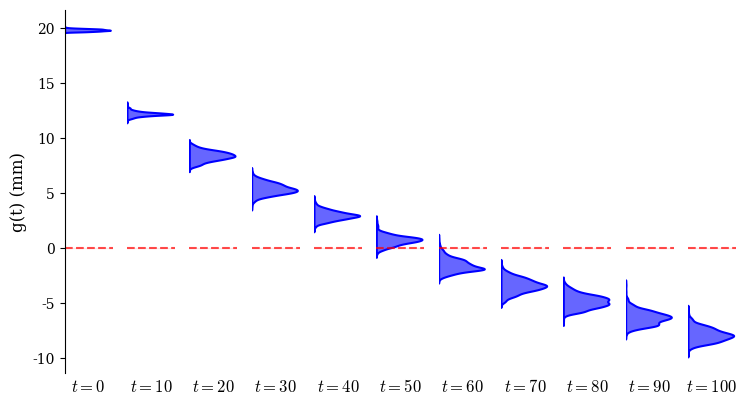

Sample 1 plot saved as 'z_durability_kde_samples_sample_1.png'


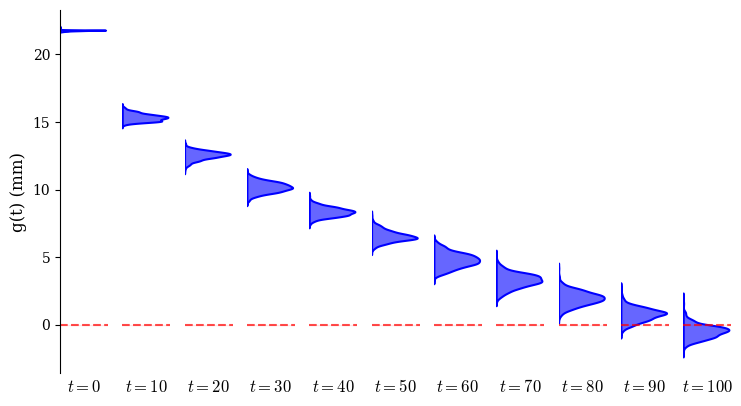

Sample 2 plot saved as 'z_durability_kde_samples_sample_2.png'


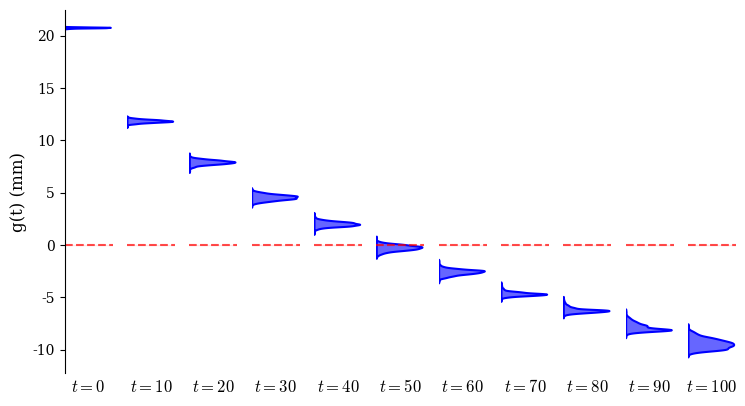

Sample 3 plot saved as 'z_durability_kde_samples_sample_3.png'


In [9]:
# INDIVIDUAL KDE PLOTS - Only for the first 4 samples
print("\nGenerating individual KDE plots for the first 4 samples...")
name = f"durability_kde_samples"

# Define how many samples to plot (maximum 4)
n_samples_to_plot = min(4, n_samples)

for sample_idx in range(n_samples_to_plot):
    fig, axes = plt.subplots(
        nrows=1, 
        ncols=len(times), 
        sharey=True, 
        figsize=(b_input_total, h_input)
    )
    
    plt.subplots_adjust(wspace=0.3)
    
    for i, ax in enumerate(axes):
        current_data = gs_by_sample[sample_idx][i]
        
        sns.kdeplot(
            y=current_data['g'], 
            fill=True, 
            alpha=0.6, 
            ax=ax, 
            color=color,
            linewidth=1.5
        )
        
        ax.axhline(0, linestyle='--', linewidth=1.5, color='red', alpha=0.7)
        ax.axhspan(-np.inf, 0, alpha=0.1, color='red')
        
        ax.set_xlabel(f'$t={int(times[i])}$', fontsize=size_label)
        ax.tick_params(axis='x', bottom=False, labelbottom=False)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        
        if i == 0:
            label_y = 'g(t) (mm)'
            ax.set_ylabel(label_y, fontsize=size_label)
            ax.tick_params(axis='y', labelsize=size_axis)
        else:
            ax.spines['left'].set_visible(False)
            ax.tick_params(axis='y', left=False)
            ax.set_ylabel('')
    
    fig.savefig(f'z_{name}_sample_{sample_idx+1}.png', dpi=dpi, bbox_inches='tight')
    plt.show()
    print(f"Sample {sample_idx+1} plot saved as 'z_{name}_sample_{sample_idx+1}.png'")

if n_samples > 4:
    print(f"\nNote: {n_samples - 4} additional samples were not plotted (limit of 4)")

# 9. AGGREGATED PLOT WITH MEAN


Generating aggregated plot with mean, percentiles and labels...


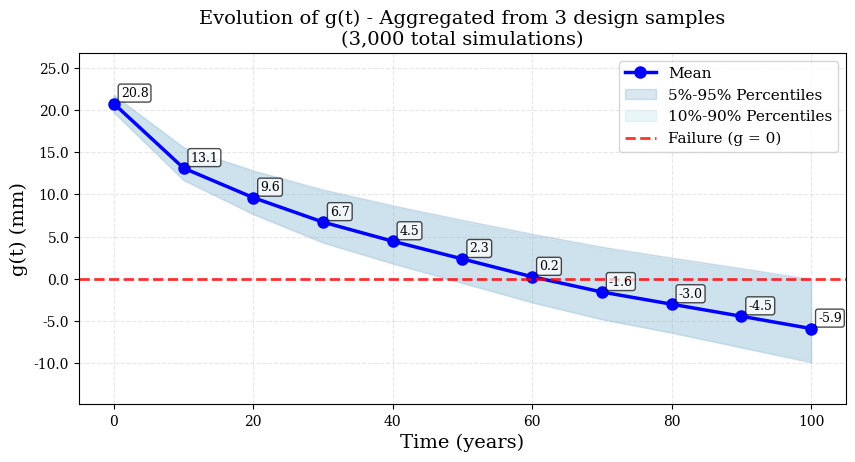

Aggregated plot saved as 'g_aggregated_with_percentiles.png'

Final statistics at t = 100 years:
   Mean of g: -5.93 mm
   Median of g: -7.92 mm
   Standard deviation: 3.93 mm
   5th Percentile: -9.95 mm
   95th Percentile: -0.05 mm


In [10]:
# AGGREGATED PLOT WITH MEAN, PERCENTILES AND LABELS
# Represents all samples in a single plot

print("\nGenerating aggregated plot with mean, percentiles and labels...")

# Calculate aggregated statistics for each time
g_means = []
g_medians = []
g_p5 = []    # 5th Percentile
g_p10 = []   # 10th Percentile
g_p90 = []   # 90th Percentile
g_p95 = []   # 95th Percentile
g_std = []

for t_idx in range(n_plots):
    # Collect all g values for this time (all samples)
    all_g = []
    for sample_idx in range(n_samples):
        all_g.extend(gs_by_sample[sample_idx][t_idx]['g'].values)
    all_g = np.array(all_g)
    
    g_means.append(np.mean(all_g))
    g_medians.append(np.median(all_g))
    g_std.append(np.std(all_g))
    g_p5.append(np.percentile(all_g, 5))
    g_p10.append(np.percentile(all_g, 10))
    g_p90.append(np.percentile(all_g, 90))
    g_p95.append(np.percentile(all_g, 95))

# Create figure
fig, ax = plt.subplots(figsize=(b_input_total, h_input))

# Plot mean line with markers
line = ax.plot(times, g_means, 'b-', linewidth=2.5, marker='o', markersize=8, label='Mean', color=color)

# Plot percentile ranges (5%-95% and 10%-90%)
ax.fill_between(times, g_p5, g_p95, alpha=0.2, color='steelblue', label='5%-95% Percentiles')
ax.fill_between(times, g_p10, g_p90, alpha=0.25, color='lightblue', label='10%-90% Percentiles')

# Add mean value labels
for i, (t, g) in enumerate(zip(times, g_means)):
    ax.annotate(f'{g:.1f}', 
                xy=(t, g), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9,
                ha='left',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Failure line
ax.axhline(0, linestyle='--', linewidth=2, color='red', alpha=0.8, label='Failure (g = 0)')

# Settings
ax.set_xlabel('Time (years)', fontsize=14)
ax.set_ylabel('g(t) (mm)', fontsize=14)
ax.set_title(f'Evolution of g(t) - Aggregated from {n_samples} design samples\n'
             f'({n_samples * n_latent_samples:,} total simulations)', fontsize=14)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=11)

# Adjust y-axis limits
y_min = min(min(g_p5), 0) - 5
y_max = max(g_p95) + 5
ax.set_ylim(y_min, y_max)

# Adjust ticks
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.savefig('g_aggregated_with_percentiles.png', dpi=600, bbox_inches='tight')
plt.show()

print(f"Aggregated plot saved as 'g_aggregated_with_percentiles.png'")
print(f"\nFinal statistics at t = {times[-1]} years:")
print(f"   Mean of g: {g_means[-1]:.2f} mm")
print(f"   Median of g: {g_medians[-1]:.2f} mm")
print(f"   Standard deviation: {g_std[-1]:.2f} mm")
print(f"   5th Percentile: {g_p5[-1]:.2f} mm")
print(f"   95th Percentile: {g_p95[-1]:.2f} mm")


Gerando gráfico agregado com média, percentis e rótulos...


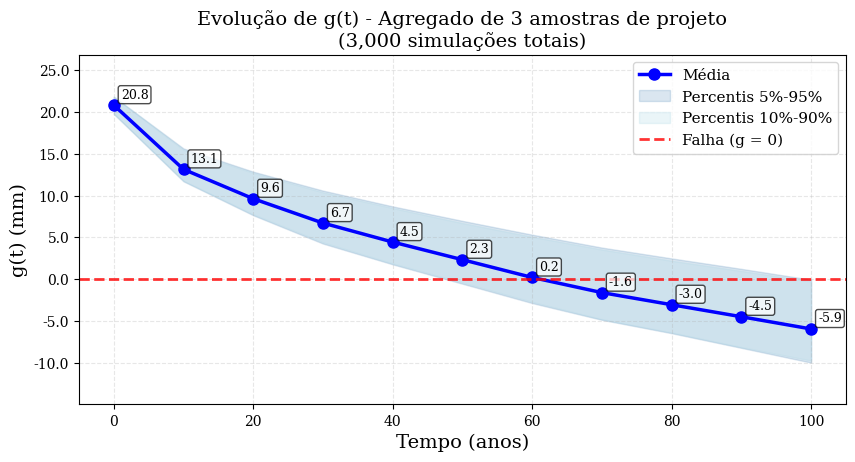

Gráfico agregado salvo como 'g_aggregated_with_percentiles.png'

Estatísticas finais em t = 100 anos:
   Média de g: -5.93 mm
   Mediana de g: -7.92 mm
   Desvio padrão: 3.93 mm
   Percentil 5%: -9.95 mm
   Percentil 95%: -0.05 mm


In [11]:
# GRÁFICO AGREGADO COM MÉDIA, PERCENTIS E RÓTULOS
# Representa todas as amostras em um único gráfico

print("\nGerando gráfico agregado com média, percentis e rótulos...")

# Calcular estatísticas agregadas para cada tempo
g_means = []
g_medians = []
g_p5 = []    # Percentil 5%
g_p10 = []   # Percentil 10%
g_p90 = []   # Percentil 90%
g_p95 = []   # Percentil 95%
g_std = []

for t_idx in range(n_plots):
    # Coletar todos os g deste tempo (todas as samples)
    all_g = []
    for sample_idx in range(n_samples):
        all_g.extend(gs_by_sample[sample_idx][t_idx]['g'].values)
    all_g = np.array(all_g)
    
    g_means.append(np.mean(all_g))
    g_medians.append(np.median(all_g))
    g_std.append(np.std(all_g))
    g_p5.append(np.percentile(all_g, 5))
    g_p10.append(np.percentile(all_g, 10))
    g_p90.append(np.percentile(all_g, 90))
    g_p95.append(np.percentile(all_g, 95))

# Criar figura
fig, ax = plt.subplots(figsize=(b_input_total, h_input))

# Plotar linha da média com marcadores
line = ax.plot(times, g_means, 'b-', linewidth=2.5, marker='o', markersize=8, label='Média', color=color)

# Plotar faixa de percentis (5%-95% e 10%-90%)
ax.fill_between(times, g_p5, g_p95, alpha=0.2, color='steelblue', label='Percentis 5%-95%')
ax.fill_between(times, g_p10, g_p90, alpha=0.25, color='lightblue', label='Percentis 10%-90%')

# Adicionar rótulos dos valores da média
for i, (t, g) in enumerate(zip(times, g_means)):
    ax.annotate(f'{g:.1f}', 
                xy=(t, g), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9,
                ha='left',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Linha de falha
ax.axhline(0, linestyle='--', linewidth=2, color='red', alpha=0.8, label='Falha (g = 0)')

# Configurações
ax.set_xlabel('Tempo (anos)', fontsize=14)
ax.set_ylabel('g(t) (mm)', fontsize=14)
ax.set_title(f'Evolução de g(t) - Agregado de {n_samples} amostras de projeto\n'
             f'({n_samples * n_latent_samples:,} simulações totais)', fontsize=14)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=11)

# Ajustar limites do eixo y
y_min = min(min(g_p5), 0) - 5
y_max = max(g_p95) + 5
ax.set_ylim(y_min, y_max)

# Ajustar ticks
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.savefig('g_aggregated_with_percentiles.png', dpi=600, bbox_inches='tight')
plt.show()

print(f"Gráfico agregado salvo como 'g_aggregated_with_percentiles.png'")
print(f"\nEstatísticas finais em t = {times[-1]} anos:")
print(f"   Média de g: {g_means[-1]:.2f} mm")
print(f"   Mediana de g: {g_medians[-1]:.2f} mm")
print(f"   Desvio padrão: {g_std[-1]:.2f} mm")
print(f"   Percentil 5%: {g_p5[-1]:.2f} mm")
print(f"   Percentil 95%: {g_p95[-1]:.2f} mm")

# 10. LAMBDAS PLOT - TEMPORAL EVOLUTION


Generating lambda evolution plots by sample...


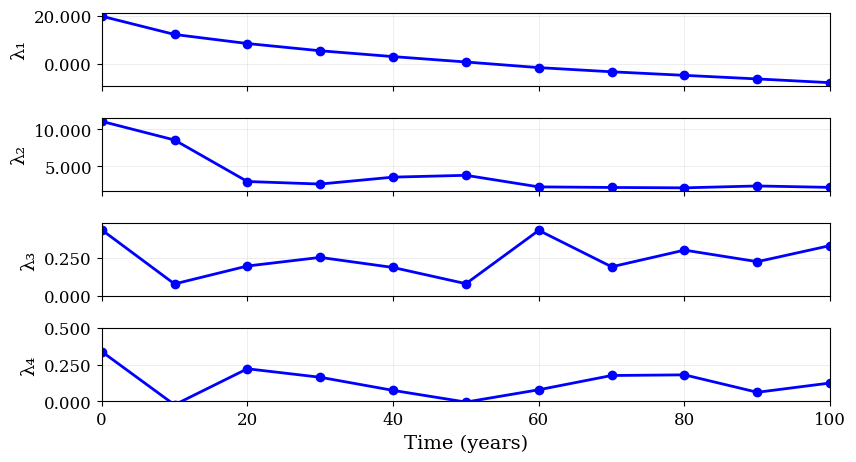

Sample 1 plot saved as 'z_lambdas_evolution_durability_sample_1.png'


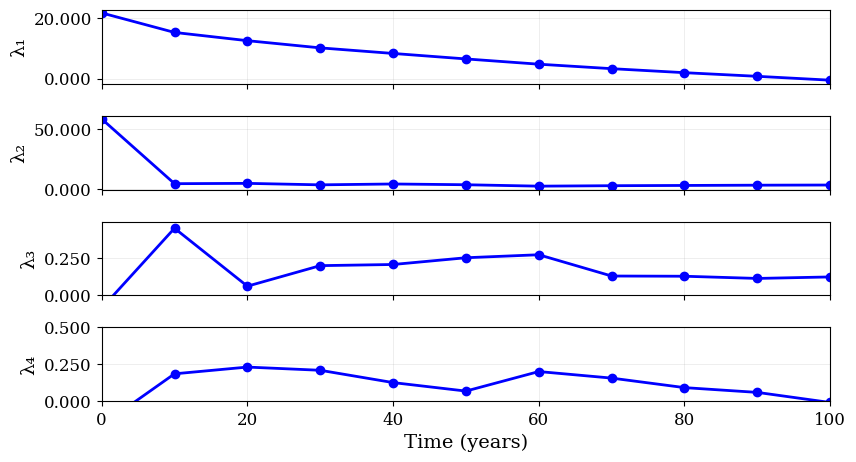

Sample 2 plot saved as 'z_lambdas_evolution_durability_sample_2.png'


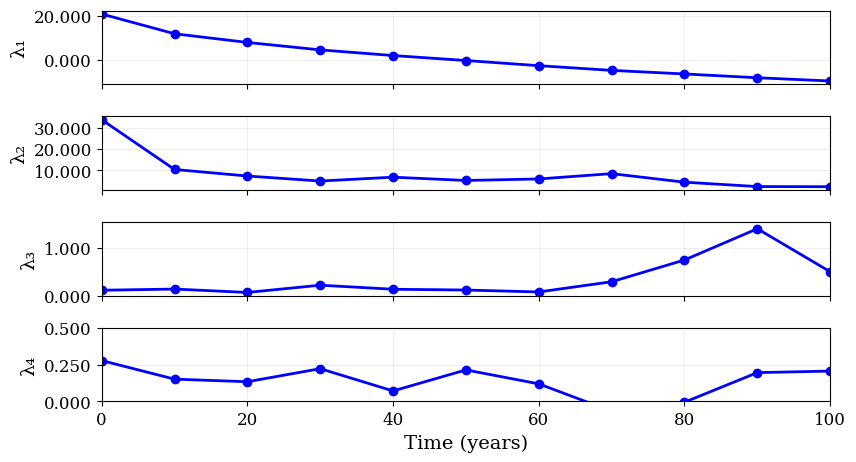

Sample 3 plot saved as 'z_lambdas_evolution_durability_sample_3.png'


In [12]:
# Visualizes the evolution of GLAM lambda parameters over time,
# now separated by sample.

print("\nGenerating lambda evolution plots by sample...")

# Settings
label_x = 'Time (years)'
size_label = 14
size_axis = 12
size_line = 2
style_line = '-'
color_line = 'blue'
marker = 'o'
size_marker = 6

# Create figure for each sample
n_samples_to_plot = min(4, n_samples)
for sample_idx in range(n_samples_to_plot):
    # Extract lambdas for this sample
    lambdas_array = np.array(lambdas_by_sample[sample_idx])
    
    if len(lambdas_array) > 0:
        y1 = lambdas_array[:, 0] if lambdas_array.shape[1] > 0 else []
        y2 = lambdas_array[:, 1] if lambdas_array.shape[1] > 1 else []
        y3 = lambdas_array[:, 2] if lambdas_array.shape[1] > 2 else []
        y4 = lambdas_array[:, 3] if lambdas_array.shape[1] > 3 else []
        
        data = [
            {'x': times, 'y': y1, 'label': 'λ₁'},
            {'x': times, 'y': y2, 'label': 'λ₂'},
            {'x': times, 'y': y3, 'label': 'λ₃'},
            {'x': times, 'y': y4, 'label': 'λ₄'}
        ]
        
        # Figure with 4 subplots
        fig, axes = plt.subplots(
            nrows=4, 
            ncols=1, 
            sharex=True, 
            figsize=(b_input_total, h_input)
        )
        
        
        # Plot
        for ax, dataset in zip(axes, data):
            # Remove NaNs for plotting
            valid_idx = ~np.isnan(dataset['y'])
            if len(dataset['y']) > 0:
                x_valid = np.array(dataset['x'])[valid_idx]
                y_valid = np.array(dataset['y'])[valid_idx]
                
                ax.plot(
                    x_valid, y_valid,
                    marker=marker,
                    markersize=size_marker,
                    linewidth=size_line,
                    linestyle=style_line,
                    color=color_line,
                    label=dataset['label']
                )
            
            ax.tick_params(axis='both', which='major', labelsize=size_axis)
            ax.set_ylabel(dataset['label'], fontsize=size_label)
            ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
            ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)
            #ax.legend(loc='best', fontsize=10)
        
        # Adjust limits
        if len(y3) > 0 and not np.all(np.isnan(y3)):
            axes[2].set_ylim(0.0, max(0.3, np.nanmax(y3) * 1.1))
        if len(y4) > 0 and not np.all(np.isnan(y4)):
            axes[3].set_ylim(0.0, max(0.5, np.nanmax(y4) * 1.1))
        
        axes[-1].set_xlim(min(times), max(times))
        axes[-1].set_xlabel(label_x, fontsize=size_label)
        
        plt.tight_layout()
        fig.savefig(f'z_lambdas_evolution_durability_sample_{sample_idx+1}.png', dpi=dpi, bbox_inches='tight')
        plt.show()
        
        print(f"Sample {sample_idx+1} plot saved as 'z_lambdas_evolution_durability_sample_{sample_idx+1}.png'")


Gerando gráficos de evolução dos lambdas por sample...


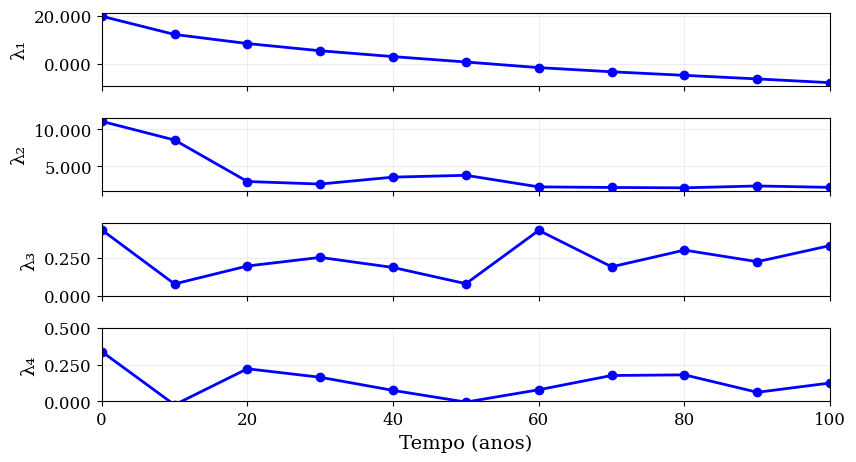

Gráfico sample 1 salvo como 'z_lambdas_evolution_durability_sample_1.png'


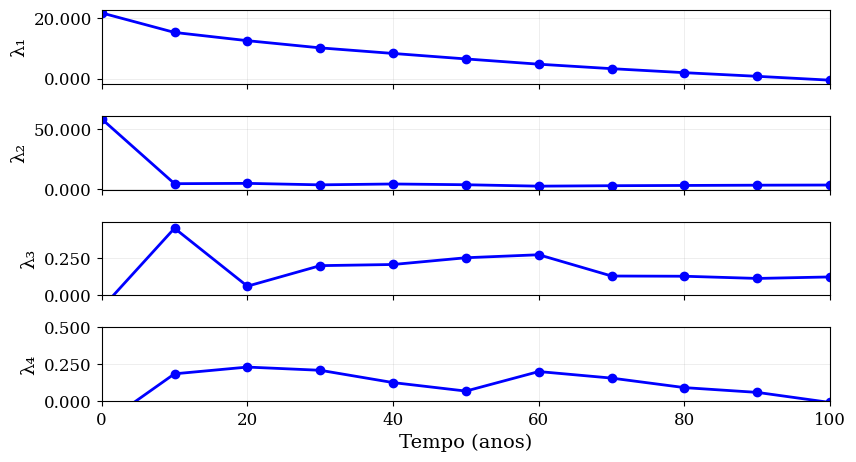

Gráfico sample 2 salvo como 'z_lambdas_evolution_durability_sample_2.png'


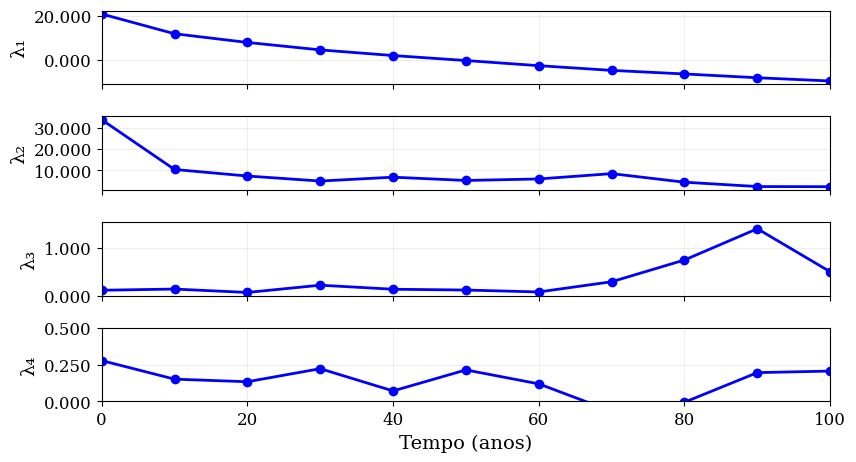

Gráfico sample 3 salvo como 'z_lambdas_evolution_durability_sample_3.png'


In [13]:
# Visualiza a evolução dos parâmetros lambda do GLAM ao longo do tempo,
# agora separado por sample.

print("\nGerando gráficos de evolução dos lambdas por sample...")

# Configurações
label_x = 'Tempo (anos)'
size_label = 14
size_axis = 12
size_line = 2
style_line = '-'
color_line = 'blue'
marker = 'o'
size_marker = 6

# Criar figura para cada sample
n_samples_to_plot = min(4, n_samples)

for sample_idx in range(n_samples_to_plot):
    # Extrair lambdas para esta sample
    lambdas_array = np.array(lambdas_by_sample[sample_idx])
    
    if len(lambdas_array) > 0:
        y1 = lambdas_array[:, 0] if lambdas_array.shape[1] > 0 else []
        y2 = lambdas_array[:, 1] if lambdas_array.shape[1] > 1 else []
        y3 = lambdas_array[:, 2] if lambdas_array.shape[1] > 2 else []
        y4 = lambdas_array[:, 3] if lambdas_array.shape[1] > 3 else []
        
        data = [
            {'x': times, 'y': y1, 'label': 'λ₁'},
            {'x': times, 'y': y2, 'label': 'λ₂'},
            {'x': times, 'y': y3, 'label': 'λ₃'},
            {'x': times, 'y': y4, 'label': 'λ₄'}
        ]
        
        # Figura com 4 subplots
        fig, axes = plt.subplots(
            nrows=4, 
            ncols=1, 
            sharex=True, 
            figsize=(b_input_total, h_input)
        )
        
        
        # Plot
        for ax, dataset in zip(axes, data):
            # Remover NaNs para plot
            valid_idx = ~np.isnan(dataset['y'])
            if len(dataset['y']) > 0:
                x_valid = np.array(dataset['x'])[valid_idx]
                y_valid = np.array(dataset['y'])[valid_idx]
                
                ax.plot(
                    x_valid, y_valid,
                    marker=marker,
                    markersize=size_marker,
                    linewidth=size_line,
                    linestyle=style_line,
                    color=color_line,
                    label=dataset['label']
                )
            
            ax.tick_params(axis='both', which='major', labelsize=size_axis)
            ax.set_ylabel(dataset['label'], fontsize=size_label)
            ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
            ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)
            #ax.legend(loc='best', fontsize=10)
        
        # Ajuste de limites
        if len(y3) > 0 and not np.all(np.isnan(y3)):
            axes[2].set_ylim(0.0, max(0.3, np.nanmax(y3) * 1.1))
        if len(y4) > 0 and not np.all(np.isnan(y4)):
            axes[3].set_ylim(0.0, max(0.5, np.nanmax(y4) * 1.1))
        
        axes[-1].set_xlim(min(times), max(times))
        axes[-1].set_xlabel(label_x, fontsize=size_label)
        
        plt.tight_layout()
        fig.savefig(f'z_lambdas_evolution_durability_sample_{sample_idx+1}.png', dpi=dpi, bbox_inches='tight')
        plt.show()
        
        print(f"Gráfico sample {sample_idx+1} salvo como 'z_lambdas_evolution_durability_sample_{sample_idx+1}.png'")

# 11. ADDITIONAL PLOT: EVOLUTION OF FAILURE PROBABILITY

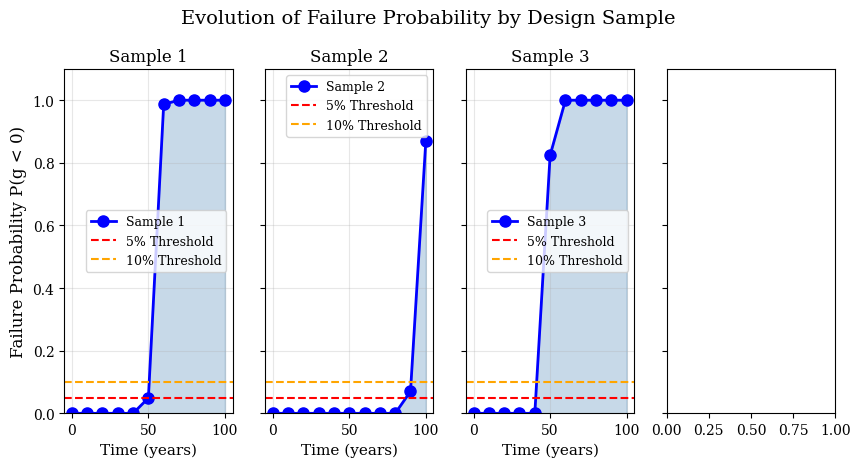

In [14]:
# Visualizes how the failure probability P(g < 0) evolves over time,
# now separated by sample.

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(b_input_total, h_input), sharey=True)

n_samples_to_plot = min(4, n_samples)

for sample_idx in range(n_samples_to_plot):
    stats_df = stats_by_sample[sample_idx]
    times_sample = stats_df['time'].values
    failure_prob_sample = stats_df['P_failure'].values
    
    ax = axes[sample_idx]
    ax.plot(times_sample, failure_prob_sample, 'b-o', linewidth=2, markersize=8, label=f'Sample {sample_idx+1}')
    ax.axhline(y=0.05, color='r', linestyle='--', linewidth=1.5, label='5% Threshold')
    ax.axhline(y=0.10, color='orange', linestyle='--', linewidth=1.5, label='10% Threshold')
    ax.fill_between(times_sample, 0, failure_prob_sample, alpha=0.3, color='steelblue')
    
    ax.set_xlabel('Time (years)', fontsize=11)
    ax.set_title(f'Sample {sample_idx + 1}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(1.0, failure_prob_sample.max() * 1.1))

axes[0].set_ylabel('Failure Probability P(g < 0)', fontsize=12)
fig.suptitle('Evolution of Failure Probability by Design Sample', fontsize=14)

plt.tight_layout()
#plt.savefig('failure_probability_by_sample.png', dpi=300, bbox_inches='tight')
plt.show()

# 12. ADDITIONAL PLOT: EVOLUTION OF CARBONATION DEPTH

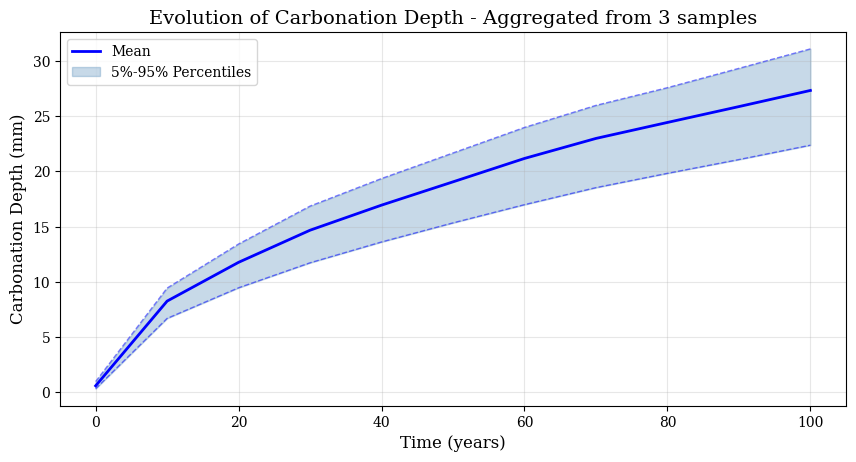

In [15]:
# Visualizes the evolution of carbonation depth over time,
# with mean and 5% and 95% percentiles to represent uncertainty.

# %%
fig, ax = plt.subplots(figsize=(b_input_total, h_input))

# Calculate percentiles for each time using aggregated data from all samples
carb_percentiles = []

for t_idx, t in enumerate(times):
    # Collect carbonation depths from all samples at this time
    all_depths = []
    for sample_idx in range(n_samples):
        all_depths.extend(gs_by_sample[sample_idx][t_idx]['Carbonation_depth_mm'].values)
    all_depths = np.array(all_depths)
    
    carb_percentiles.append({
        'mean': np.mean(all_depths),
        'p5': np.percentile(all_depths, 5),
        'p95': np.percentile(all_depths, 95),
        'median': np.median(all_depths),
        'std': np.std(all_depths)
    })

carb_mean = [p['mean'] for p in carb_percentiles]
carb_p5 = [p['p5'] for p in carb_percentiles]
carb_p95 = [p['p95'] for p in carb_percentiles]

ax.plot(times, carb_mean, 'b-', linewidth=2, label='Mean')
ax.fill_between(times, carb_p5, carb_p95, alpha=0.3, color='steelblue', label='5%-95% Percentiles')
ax.plot(times, carb_p5, 'b--', linewidth=1, alpha=0.5)
ax.plot(times, carb_p95, 'b--', linewidth=1, alpha=0.5)

ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Carbonation Depth (mm)', fontsize=12)
ax.set_title(f'Evolution of Carbonation Depth - Aggregated from {n_samples} samples', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
#plt.savefig('carbonation_depth_evolution.png', dpi=600, bbox_inches='tight')
plt.show()

# 13. ADDITIONAL PLOT: COVER vs CARBONATION DEPTH RELATIONSHIP

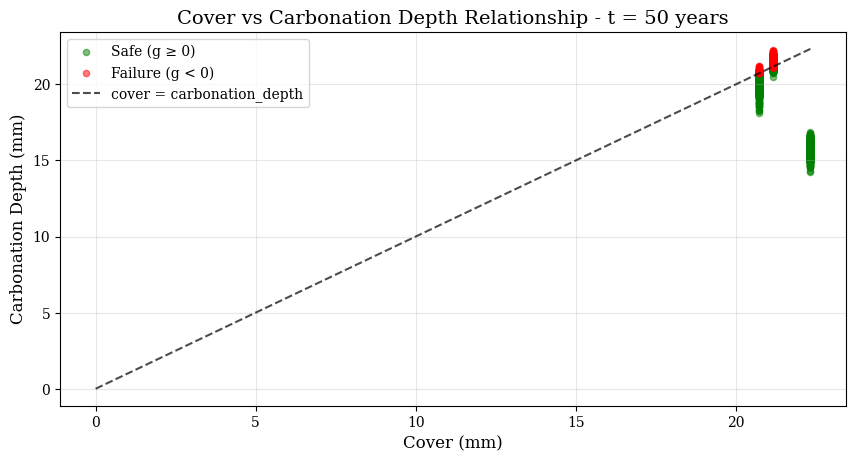

   Safe samples: 2127
   Failed samples: 873


In [16]:
# Visualizes the relationship between cover and carbonation depth at t=50 years,
# identifying samples that fail (g < 0).

# %%
# Select analysis time
t_analysis = 50

# Find the index of the time in the times array
if t_analysis in times:
    t_idx = list(times).index(t_analysis)
    
    fig, ax = plt.subplots(figsize=(b_input_total, h_input))
    
    # Collect data from all samples at this time
    all_cover = []
    all_depth = []
    all_g = []
    
    for sample_idx in range(n_samples):
        df_sample = gs_by_sample[sample_idx][t_idx]
        all_cover.extend(df_sample['Cover_mm'].values)
        all_depth.extend(df_sample['Carbonation_depth_mm'].values)
        all_g.extend(df_sample['g'].values)
    
    all_cover = np.array(all_cover)
    all_depth = np.array(all_depth)
    all_g = np.array(all_g)
    
    # Separate safe and failed samples
    safe_mask = all_g >= 0
    failed_mask = all_g < 0
    
    safe_cover = all_cover[safe_mask]
    safe_depth = all_depth[safe_mask]
    failed_cover = all_cover[failed_mask]
    failed_depth = all_depth[failed_mask]
    
    # Plot
    ax.scatter(safe_cover, safe_depth, 
               alpha=0.5, s=20, c='green', label='Safe (g ≥ 0)')
    ax.scatter(failed_cover, failed_depth, 
               alpha=0.5, s=20, c='red', label='Failure (g < 0)')
    
    # Equality line (cover = carbonation_depth)
    max_val = max(all_cover.max(), all_depth.max())
    x_line = np.linspace(0, max_val, 100)
    ax.plot(x_line, x_line, 'k--', linewidth=1.5, alpha=0.7, label='cover = carbonation_depth')
    
    ax.set_xlabel('Cover (mm)', fontsize=12)
    ax.set_ylabel('Carbonation Depth (mm)', fontsize=12)
    ax.set_title(f'Cover vs Carbonation Depth Relationship - t = {t_analysis} years', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    #plt.savefig('cover_vs_carbonation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"   Safe samples: {len(safe_cover)}")
    print(f"   Failed samples: {len(failed_cover)}")
else:
    print(f"Time {t_analysis} not found in results")
